# Examining a vertical cross section for a specific MPAS variable

In this notebook, we present a simple way to analyze a cross section for any MPAS variable that we want to analyze.

In [3]:
import uxarray
import numpy as np
import xarray as xr

import matplotlib.tri as tri
import matplotlib.pyplot as plt
 
from scipy.interpolate import griddata 

First, a function to vertically interpolate our dataset (i.e., working along a cross-section) is defined. Explanations of each variable within the function are found in the code below:

In [10]:
def vertical_interpolate_mpas(vcoord_2d, vinterp_2d, plev_1d):
    '''
    A function to interpolate MPAS grid data  to
    specified millibar. Assumes a log-linear relationship.
    input:
        vcoord_2d  : 2D vertical level values (e.g., pressure )
        vinterp_2d : 2D array of the variable to be interpolated to all pressure levels
        plev_1d    : 1D array containing veritcal levels to interpolate to
    return:
        interp_2d : 2D array that contains the interpolated variable on the interp_levels
    '''
    interp_2d = np.empty((len(plev_1d), vinterp_2d.shape[0]))
    
    for nc in range(vinterp_2d.shape[0]):
       interp_2d[:,nc] = vertical_interpolate(vcoord_2d[nc].values, vinterp_2d[nc].values, plev_1d)    
    
    return interp_2d


# from https://github.com/Unidata/python-training/blob/master/pages/gallery/Observational_Data_Cross_Section.ipynb
# The vertical interpolation assumes a log-linear relationship.
def vertical_interpolate(vcoord_data, interp_var, interp_levels):
    """
    A function to interpolate sounding data from each station to
    every millibar. Assumes a log-linear relationship.

    Input
    -----
    vcoord_data : A 1D array of vertical level values (e.g., pressure from a radiosonde)
    interp_var : A 1D array of the variable to be interpolated to all pressure levels
    interp_levels : A 1D array containing veritcal levels to interpolate to

    Return
    ------
    interp_data : A 1D array that contains the interpolated variable on the interp_levels
    """

    # Make veritcal coordinate data and grid level log variables
    lnp = np.log(vcoord_data)
    lnp_intervals = np.log(interp_levels)

    # Use numpy to interpolate from observed levels to grid levels
    interp_data = np.interp(lnp_intervals[::-1], lnp[::-1], interp_var[::-1])[::-1]

    # Mask for missing data (generally only near the surface)
    mask_low = interp_levels > vcoord_data[0]
    mask_high = interp_levels < vcoord_data[-1]
    interp_data[mask_low] = interp_var[0]
    interp_data[mask_high] = interp_var[-1]

    return interp_data

#### Read MPAS Cells

Provide MPAS initial file in this section. 

In [11]:
flnm_ini = '~/mpasviewer-cookbook/data/x1.40962.init.nc'
ds_i = xr.open_dataset(flnm_ini)
ds_i = ds_i.squeeze()

# Convert to degrees from radians
ds_i["lonCell"] = np.degrees(ds_i.lonCell)
ds_i["latCell"] = np.degrees(ds_i.latCell)

# For Global tripcolor plot
# Add cyclic point before computing the triangulation
ds_i["lonCell"] = ((ds_i["lonCell"] + 180) % 360) - 180

# MPAS data point coordinates.
points = np.array([ds_i["lonCell"].values , ds_i["latCell"].values]).transpose()

triang = tri.Triangulation(ds_i.lonCell, ds_i.latCell)


#### Cross section setup

To set up our cross section, we need to define two points: a starting point (lat_start, lon_start) and an ending point (lat_end, lon_end). We then define how many samples we want to analyze between the starting point and the ending point, which is being represented by n_pt.

In [12]:
# # Create the start point and end point for the cross section
# Points at which to interpolate data.
lat_start, lon_start = (39,-120)
lat_end, lon_end = (39, -70)

# number of sample between start and end point
n_pt = 50
lat_1d = np.linspace(lat_start, lat_end, n_pt)
lon_1d = np.linspace(lon_start, lon_end, n_pt)


#### Specify pressure levels

Simmilarly, we define our starting and ending points along our vertical axis, and the number of samples we want to analyze between the two.

Our starting point (surface) is defined as 1000.
Our ending point is defined as 50. 
Our increment interval, in this case, is defined as -100. Modify values based on your needs!

In [13]:
# veritcal levels to interpolate to
p_1d = np.atleast_1d(np.arange(1000, 50, -100)) # hPa
n_p = len(p_1d)

#### Read MPAS variable

Here, define the variable you need to analyze. In this example, we are choosing 'theta'. Don't forget to provide the MPAS output file!

In [15]:
# the variable to be interpolated 
var_s = 'theta'

flnm = '~/mpasviewer-cookbook/data/restart.2011-04-24_00.00.00.nc'
ds = xr.open_dataset(flnm)
ds = ds.squeeze()

theta = ds[var_s]              # theta(nCells, nVertLevels)
pressure_b = ds.pressure_base  # pressure_base(nCells, nVertLevels)
pressure_p = ds.pressure_p     # pressure_p(nCells, nVertLevels)
 
pres = 0.01*(pressure_b + pressure_p)  #hPa


#### Vertical interpolation  

In [16]:
var_2d = vertical_interpolate_mpas(pres, theta, p_1d)


#### Horizontal interpolation

In [17]:
hh_2d = np.empty((n_p, n_pt))

ct = 0
for nn in p_1d:
    # method='linear', 'cubic', 'nearest'
    hh_2d[ct, :] = griddata(points, var_2d[ct,:], (lon_1d, lat_1d), method='linear')
    ct = ct + 1    

#### Plotting

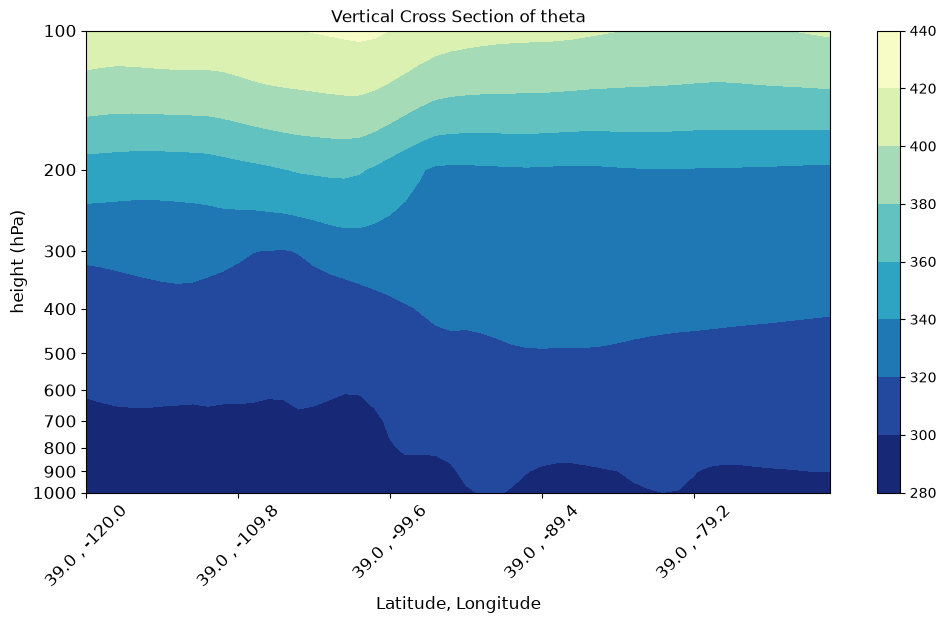

In [18]:
# Create the figure
fig = plt.figure(figsize=(12,6))
ax = plt.axes()

# Make the contour plot
# contourf([X= range(N), Y= range(M),] Z(M, N), [levels], **kwargs)
t_cs = ax.contourf(np.arange(n_pt), np.arange(1000, 50, -100), hh_2d, cmap='YlGnBu_r')

# Add the color bar
plt.colorbar(t_cs, ax=ax)

# Set the x-ticks to use latitude and longitude labels.
x_labels = ["%.1f" % pair[1] + ' , ' +  "%.1f" % pair[0] for pair in np.array([lon_1d, lat_1d]).transpose()]
ax.set_xticks(np.arange(n_pt)[::10])
ax.set_xticklabels(x_labels[::10], rotation=45, fontsize=12);

# Set the y-ticks to be height and adjust the y-axis to be logarithmic
ax.set_yscale('symlog')
ax.set_ylim(p_1d.max(), p_1d.min())
ax.set_yticks(np.arange(1000, 50, -100))
ax.set_yticklabels(p_1d, fontsize=12)

# Set the x-axis and  y-axis labels
ax.set_xlabel("Latitude, Longitude", fontsize=12)
ax.set_ylabel("height (hPa)", fontsize=12)

plt.title("Vertical Cross Section of theta");
